# Link Power Point

https://www.canva.com/design/DAHDP2HKtQY/S_FPgqZzBsG8fPktQMv9-A/edit?utm_content=DAHDP2HKtQY&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton

#Persiapan Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Penyaluran Kerja/Interview Data Analyst/ds/train (2).csv')
df.sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
50344,"Indianapolis Airport Courtyard Indianapolis, IN",1,253,2017,September,37,12,2,5,2,...,96.0,NaN,0,Transient,58.95,0,0,Canceled,2017-06-17,50345
10995,Sheraton Mexico City Maria Isabel Hotel Mexico...,0,225,2018,June,26,23,2,5,2,...,40.0,NaN,0,Transient,79.84,0,0,Check-Out,2018-06-30,10996
15040,Irvine John Wayne Airport/Orange County Courty...,0,19,2018,January,1,1,1,2,2,...,9.0,NaN,0,Transient,194.67,1,0,Check-Out,2018-01-04,15041
46187,"Grosvenor House, A JW Marriott Hotel London, U...",0,100,2019,April,17,29,2,1,2,...,385.0,NaN,0,Transient-Party,83.00,0,1,Check-Out,2019-05-02,46188
44171,"Sheraton Lima Hotel & Convention Center Lima, ...",1,133,2018,August,33,13,4,6,2,...,250.0,NaN,0,Transient,289.90,0,0,Canceled,2018-07-15,44172
26467,Sheraton Mexico City Maria Isabel Hotel Mexico...,1,10,2018,February,7,9,0,3,2,...,9.0,NaN,0,Transient-Party,93.00,0,1,No-Show,2018-02-09,26468
53674,Protea Hotel Fire & Ice! by Marriott Cape Town...,1,41,2019,July,30,29,1,1,2,...,9.0,NaN,0,Transient,140.00,0,1,Canceled,2019-07-14,53675
33048,"Indianapolis Airport Courtyard Indianapolis, IN",1,418,2018,September,40,26,1,2,2,...,21.0,NaN,223,Transient-Party,75.00,0,0,Canceled,2018-07-08,33049
19778,Marriott Puerto Vallarta Resort & Spa Puerto V...,1,277,2018,November,46,7,1,2,2,...,NaN,NaN,0,Transient,100.00,0,0,Canceled,2018-04-04,19779
9844,Protea Hotel Fire & Ice! by Marriott Cape Town...,0,34,2017,September,39,23,0,3,2,...,52.0,NaN,33,Transient-Party,224.67,0,0,Check-Out,2017-09-26,9845


# Pemahaman Dataset

## Datatype

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

In [ ]:
def hitung_tipe_kolom(df):
    # Hitung kolom object
    object_count = df.select_dtypes(include=['object']).shape[1]

    # Hitung kolom numeric
    numeric_count = df.select_dtypes(include=['int64', 'float64']).shape[1]

    # Hitung kolom datetime
    datetime_count = df.select_dtypes(include=['datetime64']).shape[1]

    return object_count, numeric_count, datetime_count

object_count, numeric_count, datetime_count = hitung_tipe_kolom(df)

print(f"Kolom Object: {object_count}")
print(f"Kolom Numeric: {numeric_count}")
print(f"Kolom Datetime: {datetime_count}")


Kolom Object: 12
Kolom Numeric: 21
Kolom Datetime: 0


In [ ]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,83293,83293,83293,82947,83293,83293,83293,83293,83293,83293,83293,83293
unique,64,12,5,165,8,5,10,11,3,4,3,914
top,Renaissance New York Times Square Hotel New Yo...,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2017-10-21
freq,1373,9643,64424,33952,39445,68368,60062,51702,72979,62535,52516,1024


**Data Overview**

1.   Jumlah Kolom = 33 Kolom
2.   Jumlah Baris = 83293
3.   Tipe Data:

    *   Kolom Bertipe Object: 12
    *   Kolom Bertipe Numeric: 21
    *   Kolom Bertipe Datetime: 0

*Note: Feature Engineering untuk membuat kolom datetime*







# Preprocessing Data

## Distribusi Data

In [ ]:
def tampilkan_kolom_numeric(df):
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    return numeric_columns

kolom_numeric = tampilkan_kolom_numeric(df)
print(kolom_numeric)

['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'bookingID']


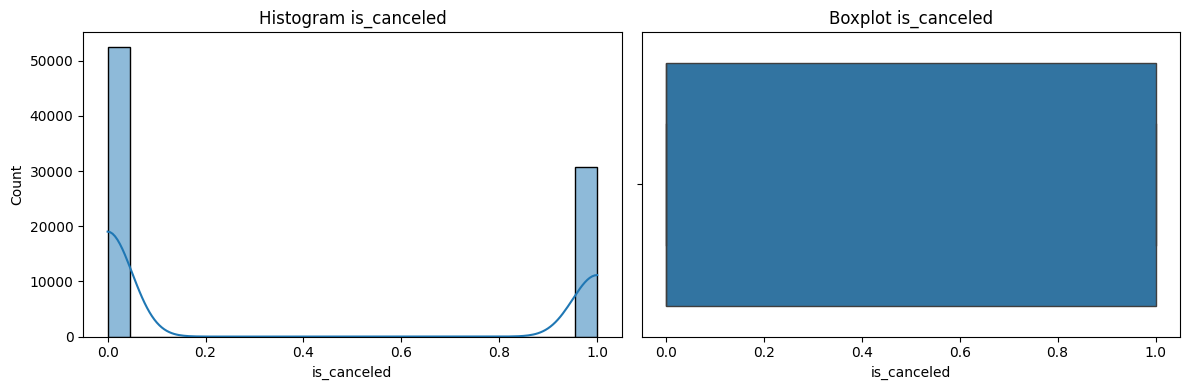

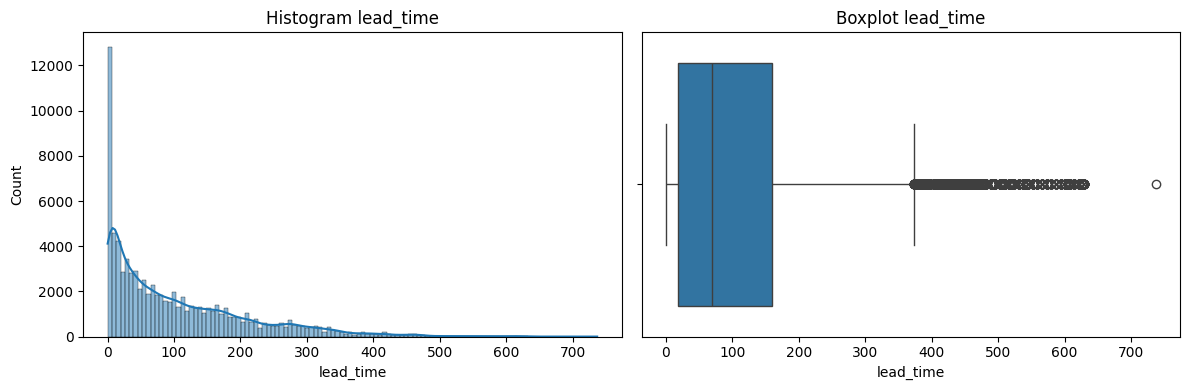

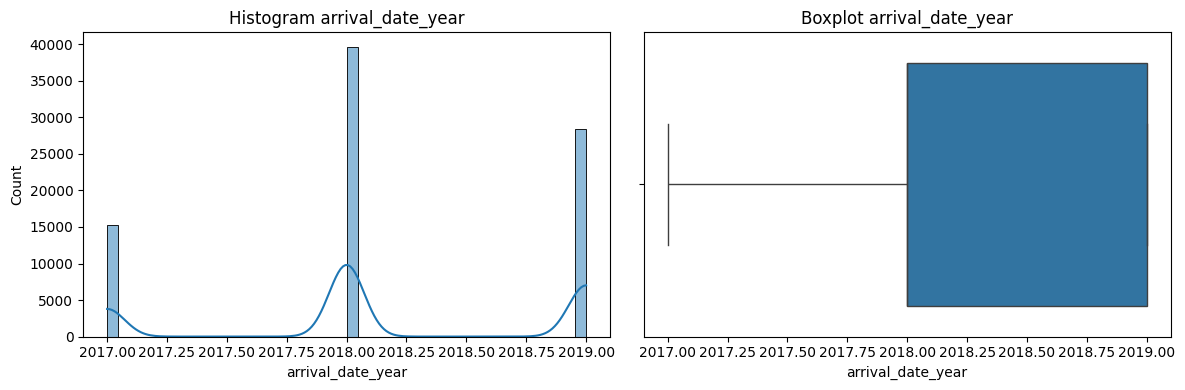

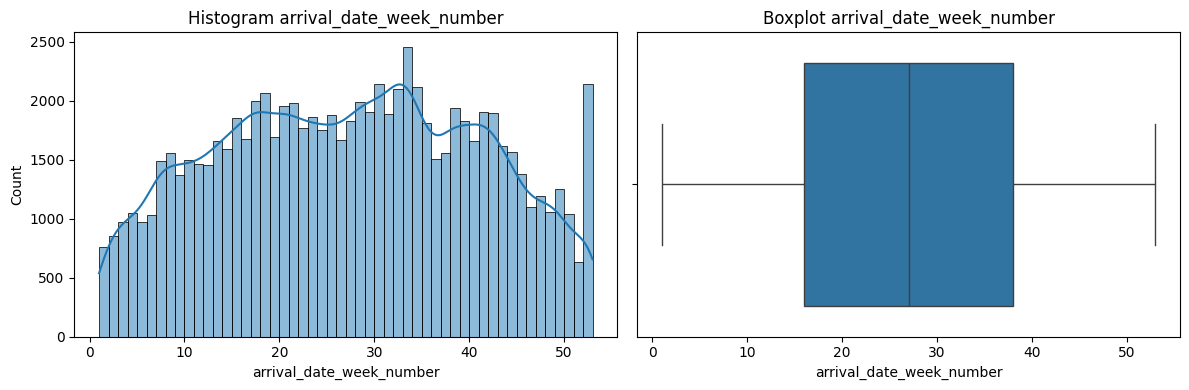

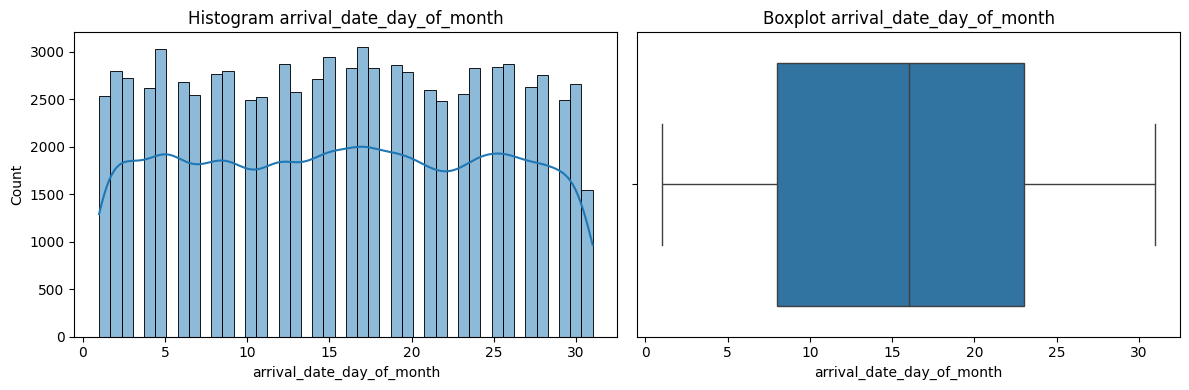

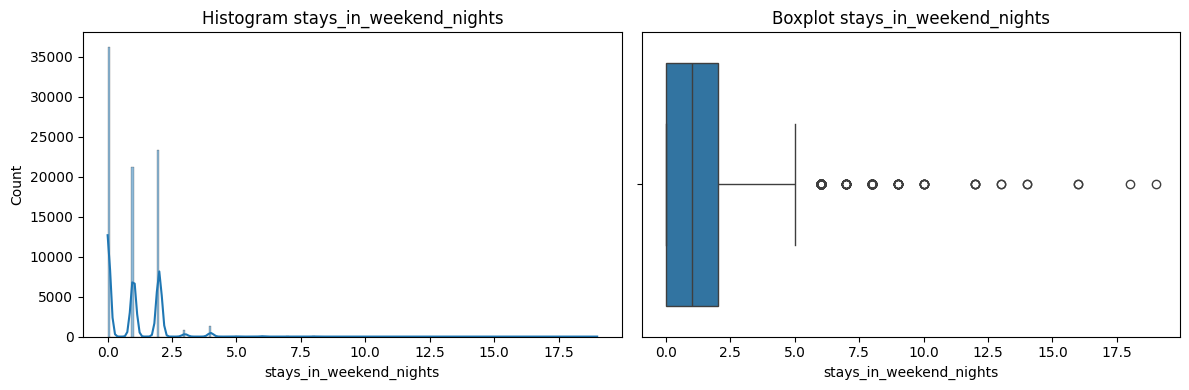

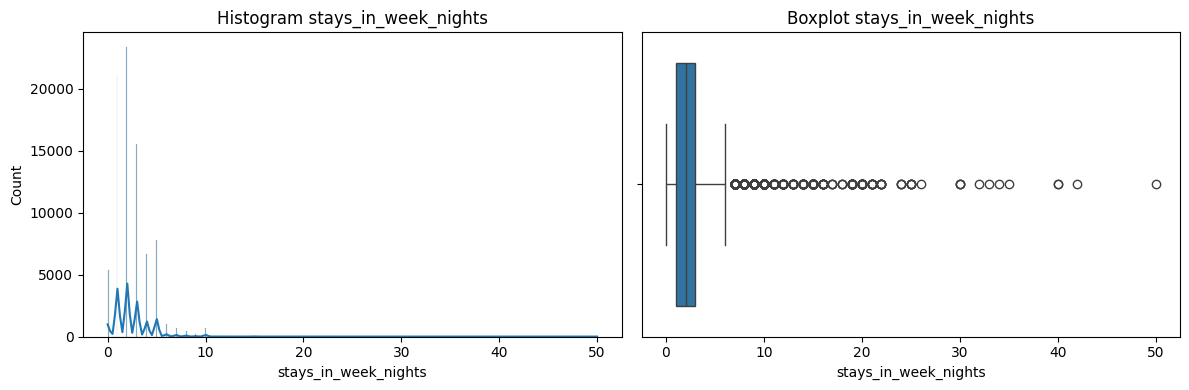

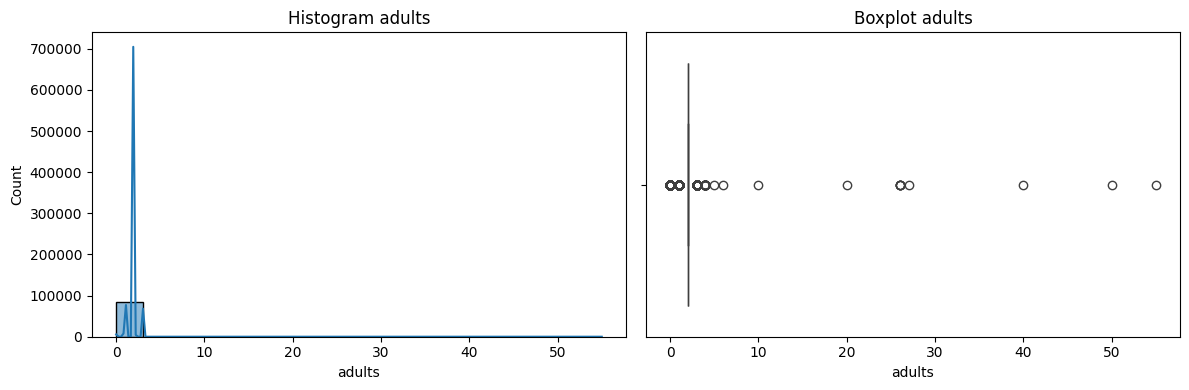

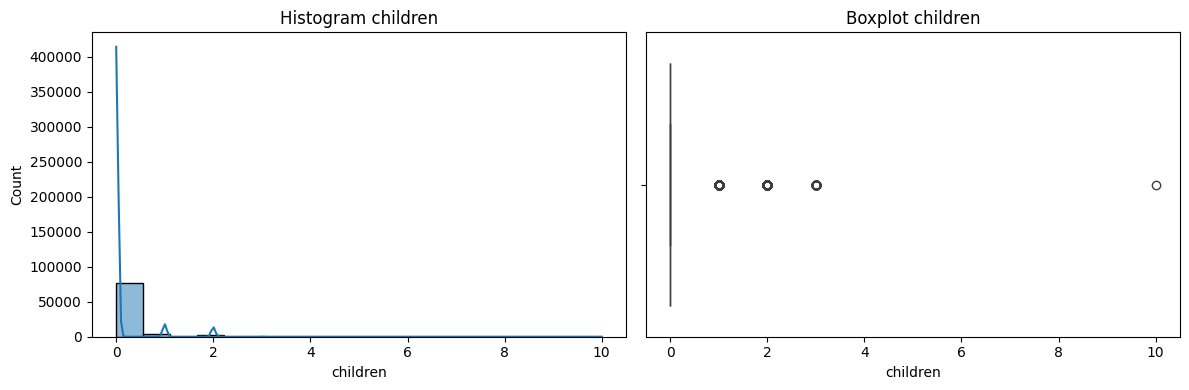

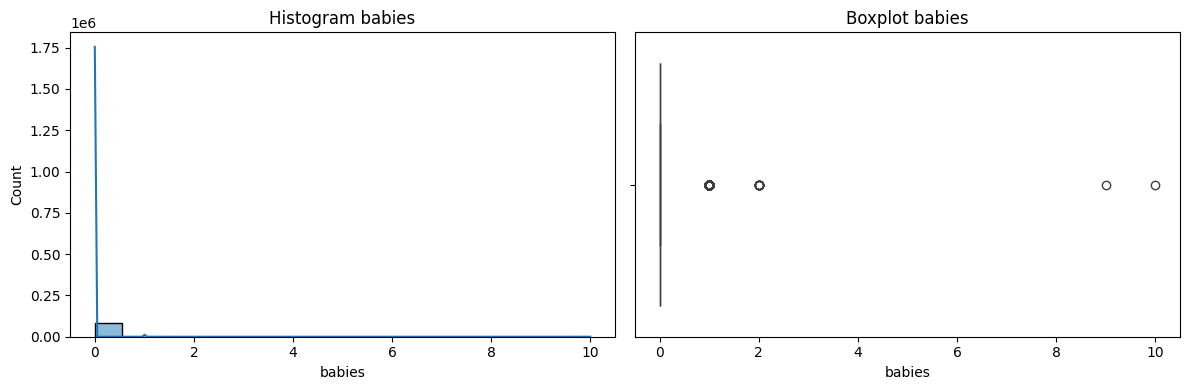

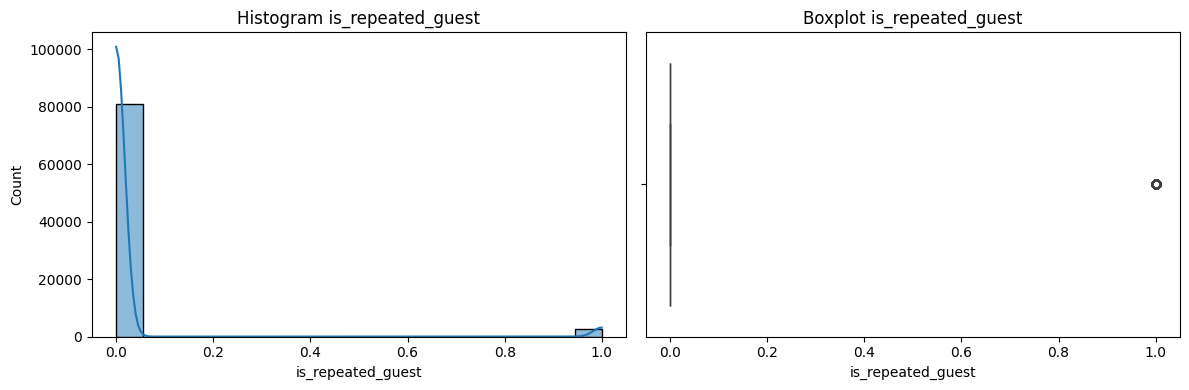

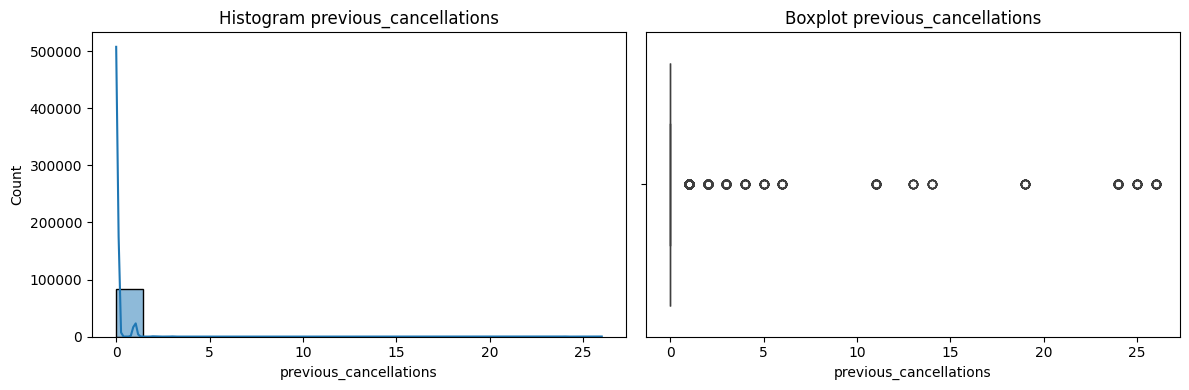

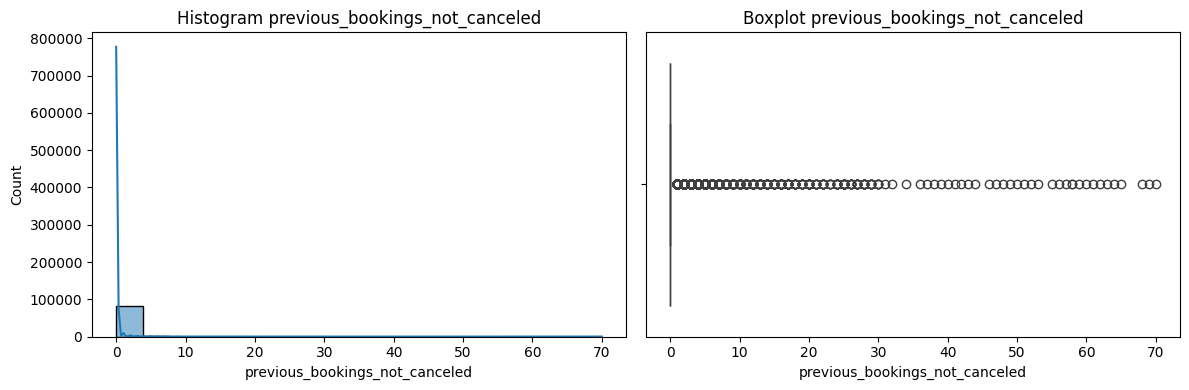

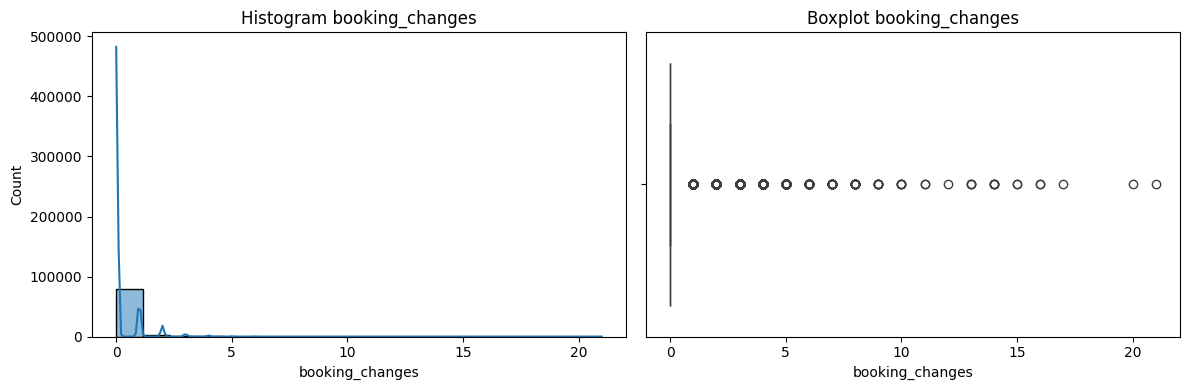

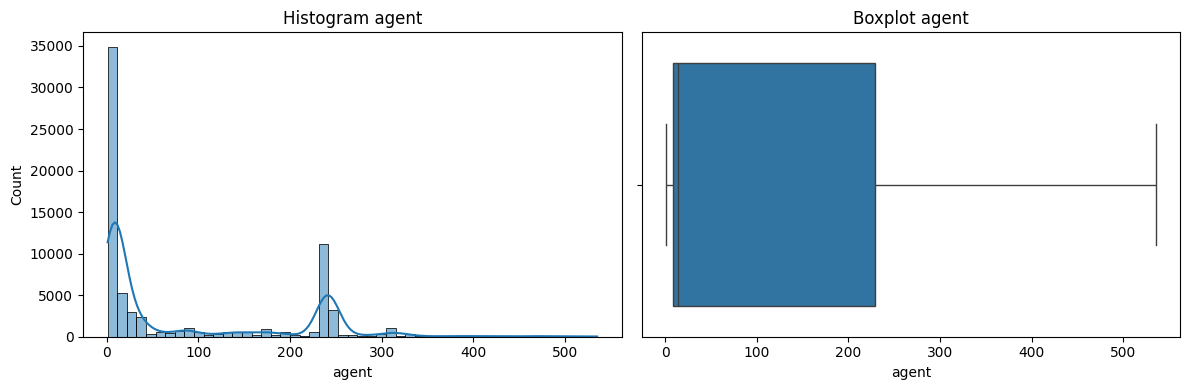

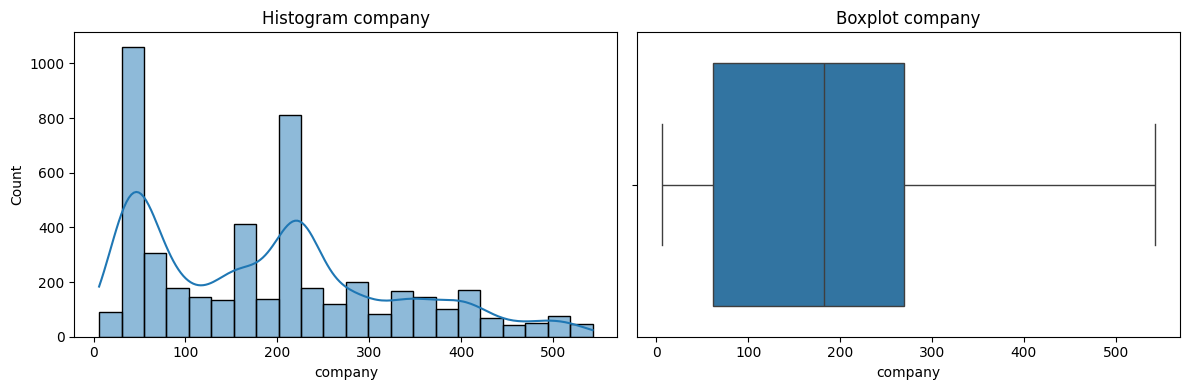

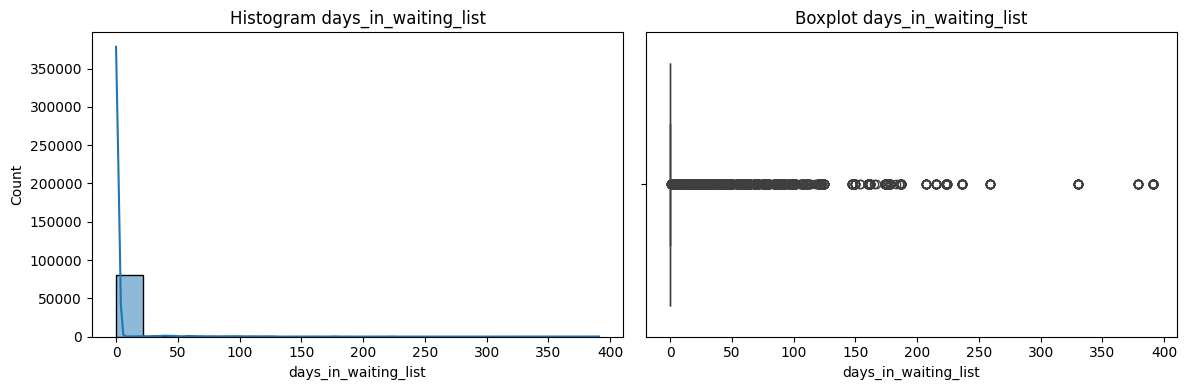

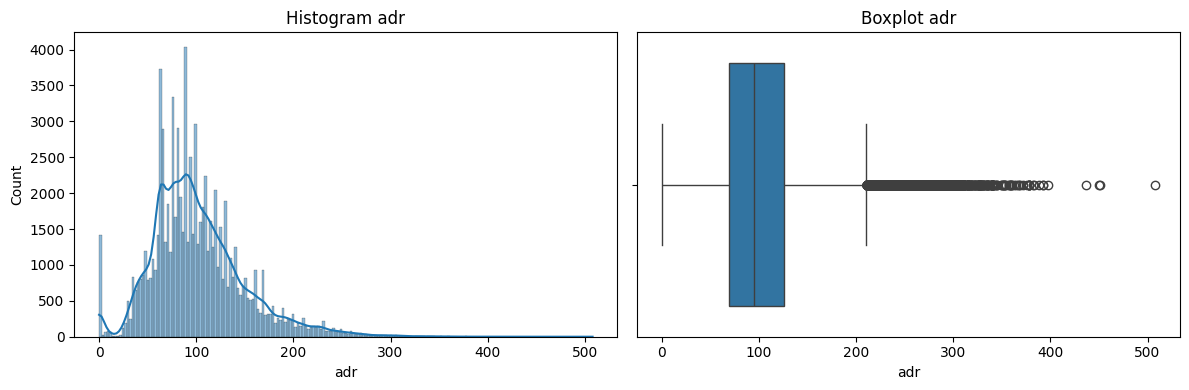

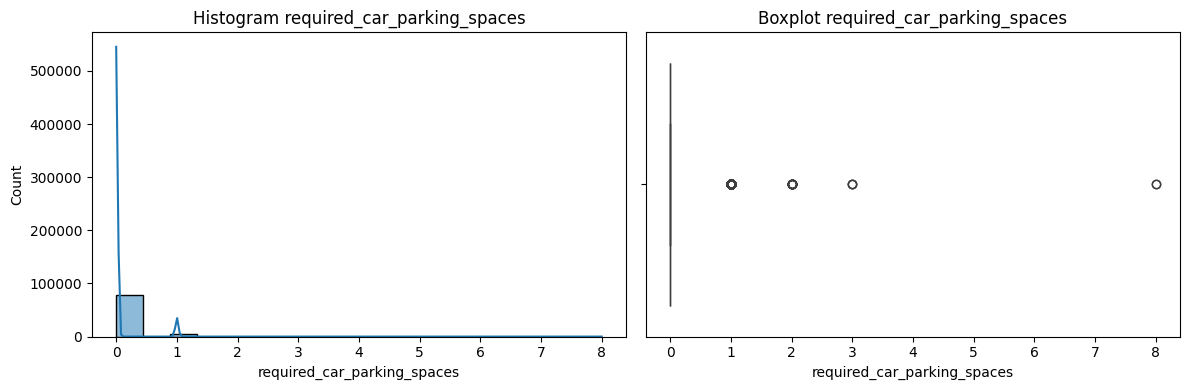

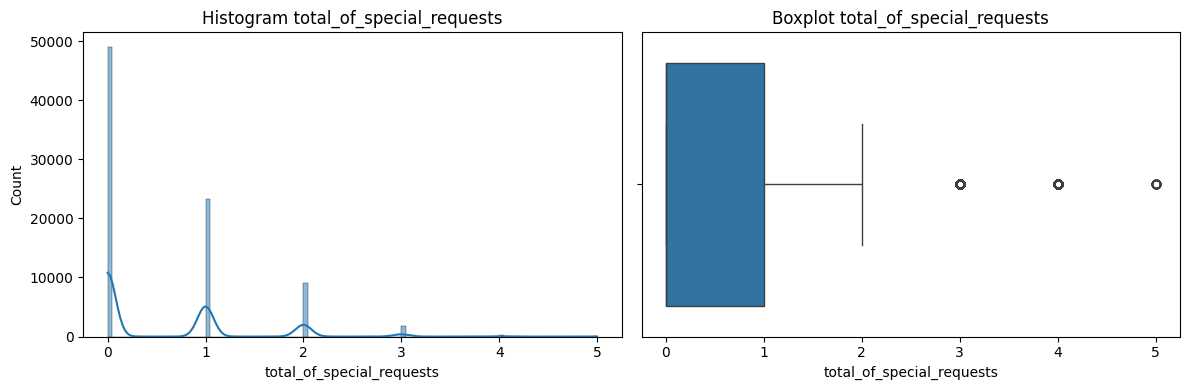

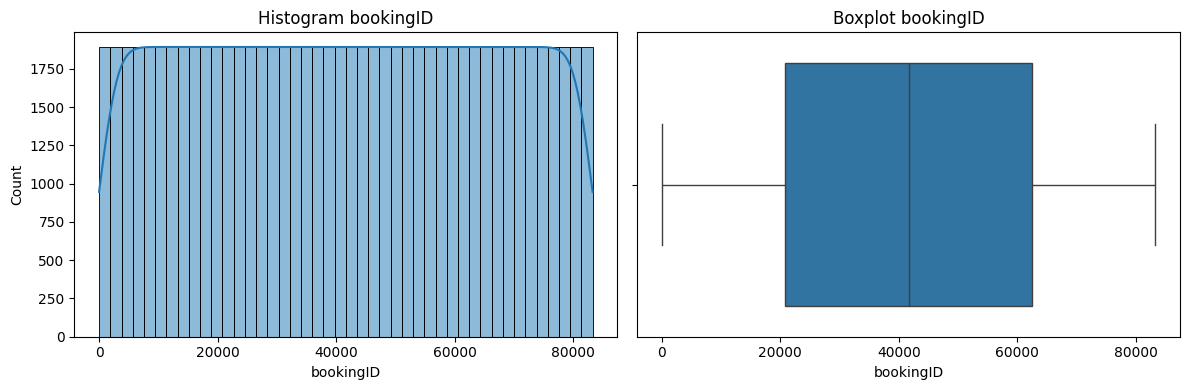

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom = ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number',
         'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
         'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
         'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
         'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
         'total_of_special_requests', 'bookingID']

for col in kolom:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], ax=ax[0], kde=True)
    ax[0].set_title(f'Histogram {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()

Sebaran data ini sangat bervariasi, untuk itu akan dilakukan handling Outlier

## Handling Duplicated Data

In [ ]:
# Cek jumlah duplikat
print(f"Jumlah duplikat: {df.duplicated().sum()}")

# Hapus duplikat
df = df.drop_duplicates()

# Cek lagi
print(f"Jumlah duplikat setelah dihapus: {df.duplicated().sum()}")

Jumlah duplikat: 0
Jumlah duplikat setelah dihapus: 0


## Handling Missing Value

In [ ]:
# Cek jumlah dan persentase missing value
missing_value = df.isnull().sum().reset_index()
missing_value.columns = ['Kolom', 'Jumlah Missing']
missing_value['Persentase Missing'] = (missing_value['Jumlah Missing'] / len(df)) * 100
missing_value = missing_value.sort_values(by='Persentase Missing', ascending=False)

print(missing_value)

                             Kolom  Jumlah Missing  Persentase Missing
24                         company           78559           94.316449
23                           agent           11404           13.691427
13                         country             346            0.415401
10                        children               3            0.003602
0                            hotel               0            0.000000
5         arrival_date_week_number               0            0.000000
6        arrival_date_day_of_month               0            0.000000
1                      is_canceled               0            0.000000
2                        lead_time               0            0.000000
8             stays_in_week_nights               0            0.000000
7          stays_in_weekend_nights               0            0.000000
11                          babies               0            0.000000
9                           adults               0            0.000000
12    

Dalam kasus data ini, Kolom "*Company*" Memiliki missing value mencapai Lebih dari 90% untuk itu kolom ini akan di drop karena tidak banyak informasi yang bisa di ambil dari kolom ini. Untuk Kolom Agent Country dan Children akan dihandling dengan nilai Mediannya.

In [ ]:
# Imputasi agent dengan modus (karena kategorik)
df['agent'] = df['agent'].fillna(df['agent'].mode()[0])

# Imputasi country dengan modus (karena kategorik)
df['country'] = df['country'].fillna(df['country'].mode()[0])

# Imputasi children dengan median (karena numerik skewed)
df['children'] = df['children'].fillna(df['children'].median())

In [ ]:
df = df.drop('company', axis=1)

In [ ]:
# Cek jumlah dan persentase missing value
missing_value = df.isnull().sum().reset_index()
missing_value.columns = ['Kolom', 'Jumlah Missing']
missing_value['Persentase Missing'] = (missing_value['Jumlah Missing'] / len(df)) * 100
missing_value = missing_value.sort_values(by='Persentase Missing', ascending=False)

print(missing_value)

                             Kolom  Jumlah Missing  Persentase Missing
0                            hotel               0                 0.0
1                      is_canceled               0                 0.0
2                        lead_time               0                 0.0
3                arrival_date_year               0                 0.0
4               arrival_date_month               0                 0.0
5         arrival_date_week_number               0                 0.0
6        arrival_date_day_of_month               0                 0.0
7          stays_in_weekend_nights               0                 0.0
8             stays_in_week_nights               0                 0.0
9                           adults               0                 0.0
10                        children               0                 0.0
11                          babies               0                 0.0
12                            meal               0                 0.0
13    

**Data Sudah Bersih dari Missing Value**

## Handling Outlier

In [ ]:
import numpy as np
# Fungsi untuk mendeteksi outlier
def detect_outlier(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier = data[(data < lower_bound) | (data > upper_bound)]
    return outlier

# Kolom yang ingin dideteksi outlier
kolom = ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number',
         'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
         'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
         'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list',
         'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'bookingID']

# Deteksi outlier
outlier_results = {}
for col in kolom:
    if df[col].dtype in ['int64', 'float64']:
        outlier = detect_outlier(df[col])
        outlier_results[col] = {
            'Jumlah Outlier': len(outlier),
            'Persentase Outlier': (len(outlier) / len(df)) * 100
        }

# Tampilkan hasil
outlier_df = pd.DataFrame(outlier_results).T.sort_values(by='Persentase Outlier', ascending=False)
print(outlier_df)


                                Jumlah Outlier  Persentase Outlier
adults                                 20920.0           25.116156
booking_changes                        12703.0           15.250981
children                                5961.0            7.156664
required_car_parking_spaces             5109.0            6.133769
previous_cancellations                  4397.0            5.278955
adr                                     2672.0            3.207953
days_in_waiting_list                    2594.0            3.114307
previous_bookings_not_canceled          2532.0            3.039871
is_repeated_guest                       2519.0            3.024264
stays_in_week_nights                    2355.0            2.827368
lead_time                               2112.0            2.535627
total_of_special_requests               2017.0            2.421572
agent                                    869.0            1.043305
babies                                   643.0            0.77

In [ ]:
# Fungsi untuk menghandling outlier menggunakan Winsorization
def winsorize(data, lower=0.05, upper=0.95):
    lower_bound = np.percentile(data, lower*100)
    upper_bound = np.percentile(data, upper*100)
    data[data < lower_bound] = lower_bound
    data[data > upper_bound] = upper_bound
    return data

# Kolom yang ingin dihandling outlier
kolom = ['adults', 'booking_changes', 'children', 'required_car_parking_spaces',
         'previous_cancellations', 'adr', 'days_in_waiting_list',
         'previous_bookings_not_canceled', 'is_repeated_guest', 'stays_in_week_nights']

# Handling outlier
for col in kolom:
    df[col] = winsorize(df[col])


/tmp/ipykernel_300/2997749438.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data < lower_bound] = lower_bound
/tmp/ipykernel_300/2997749438.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data > upper_bound] = upper_bound
/tmp/ipykernel_300/2997749438.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data < lower_bound] = lower_bound
/tmp/ipykernel_300/2997749438.py:6: SettingWithCopyWarning: 
A value is tryi

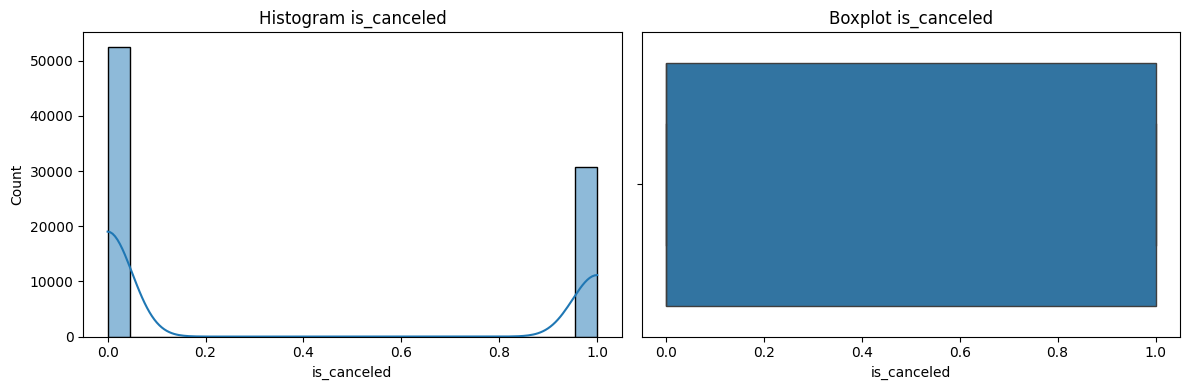

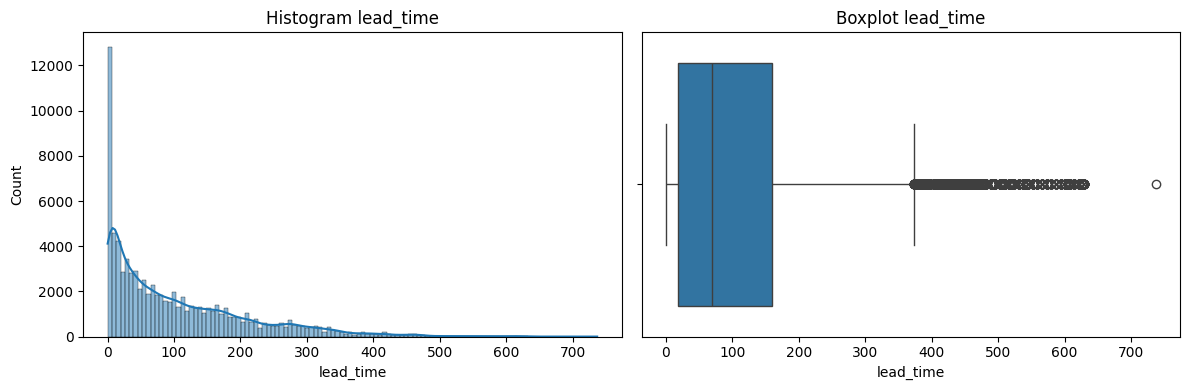

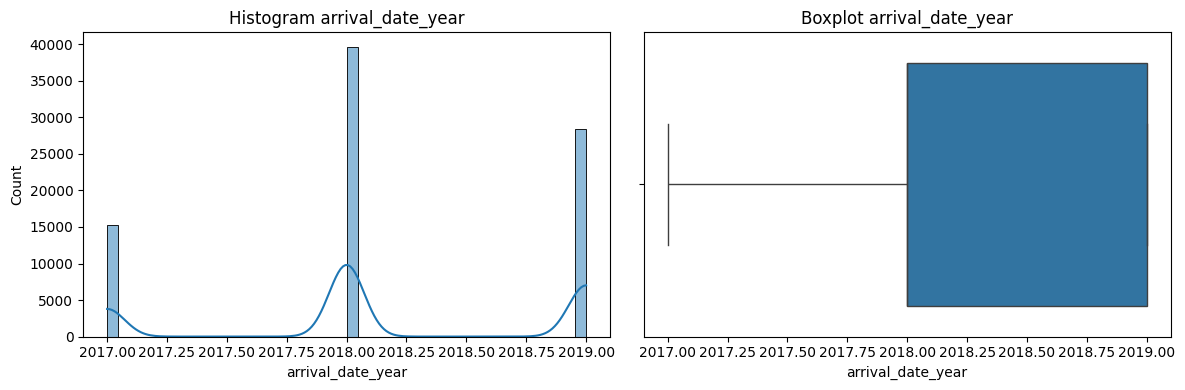

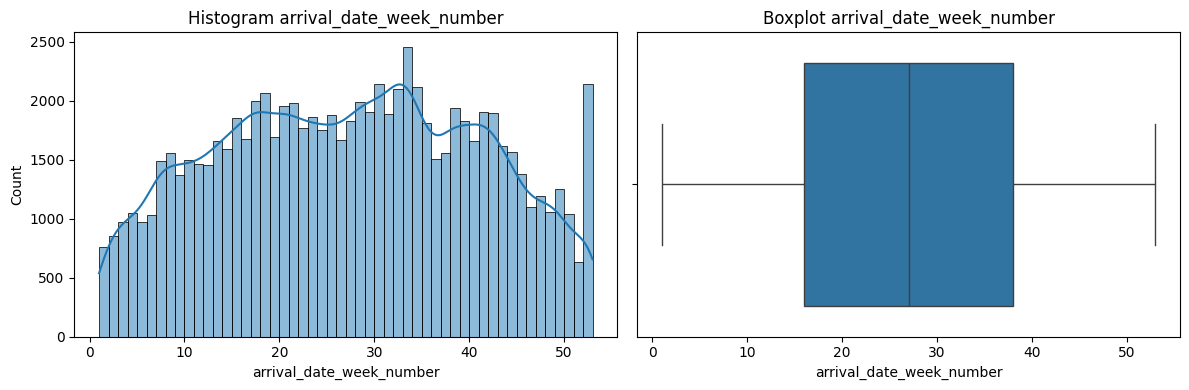

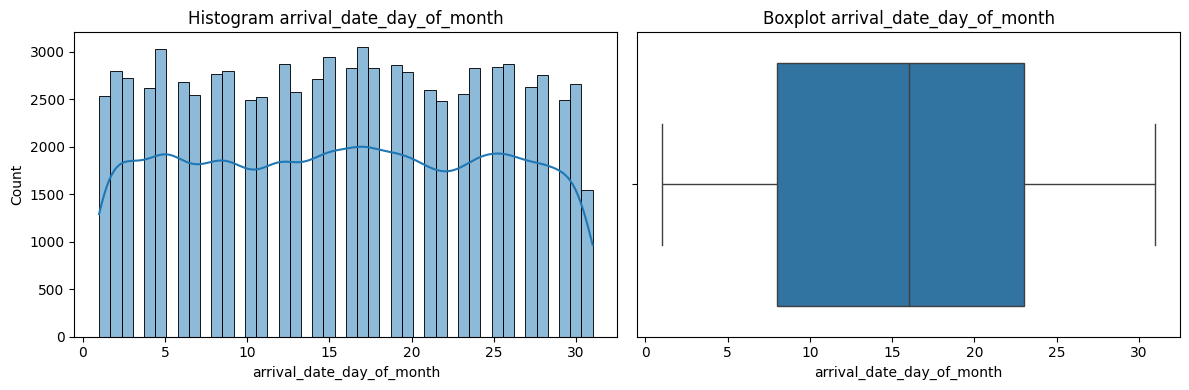

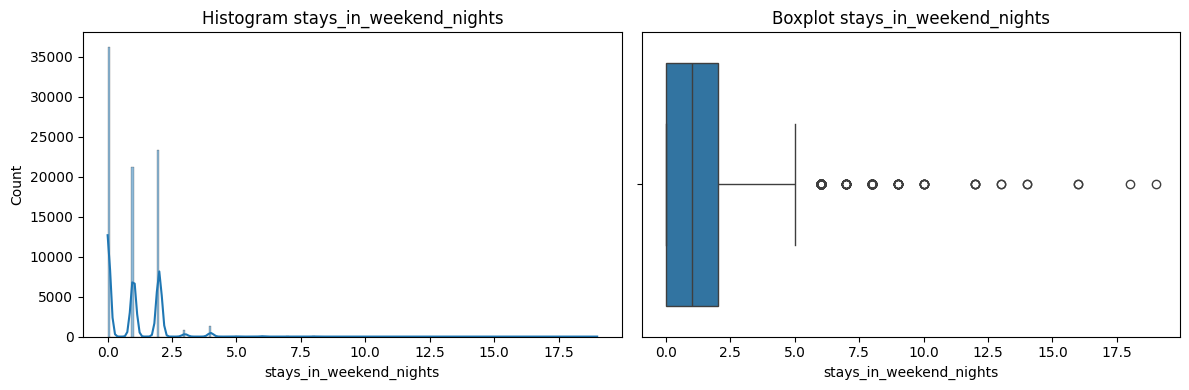

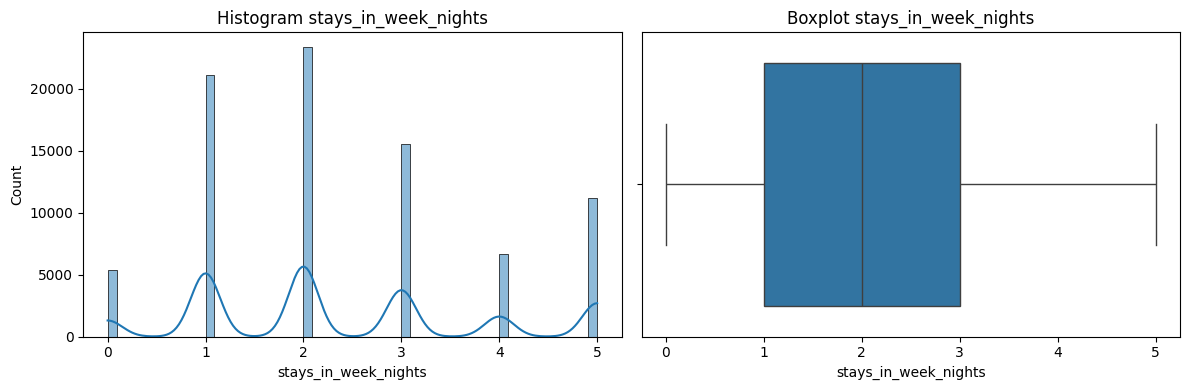

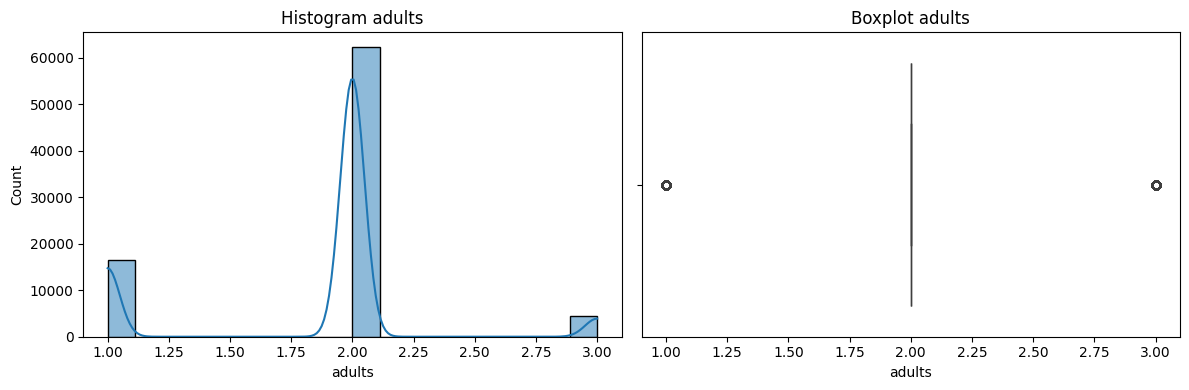

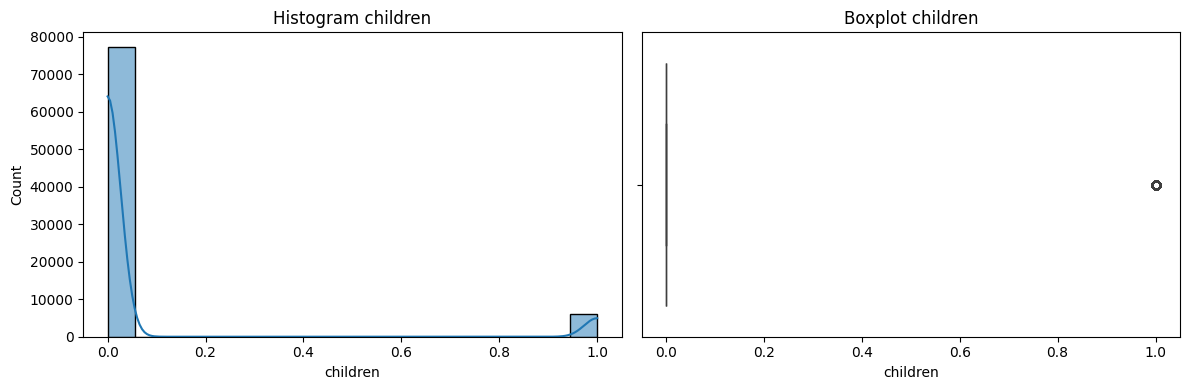

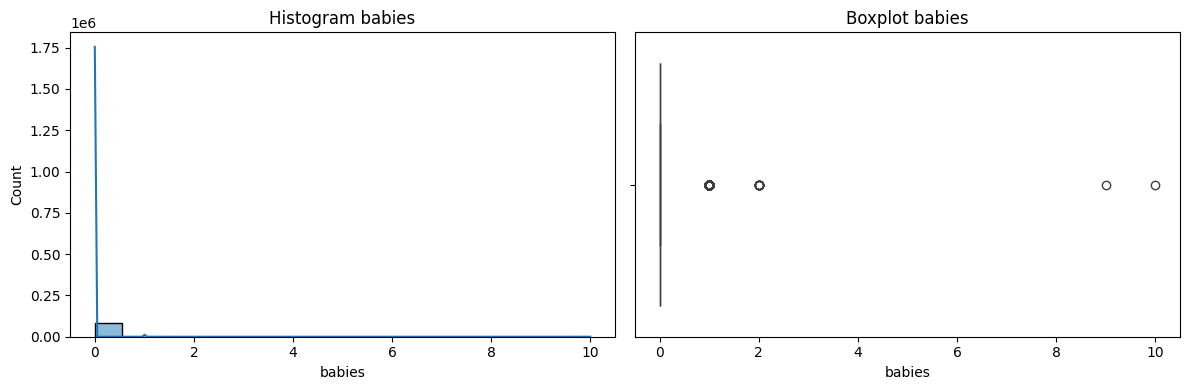

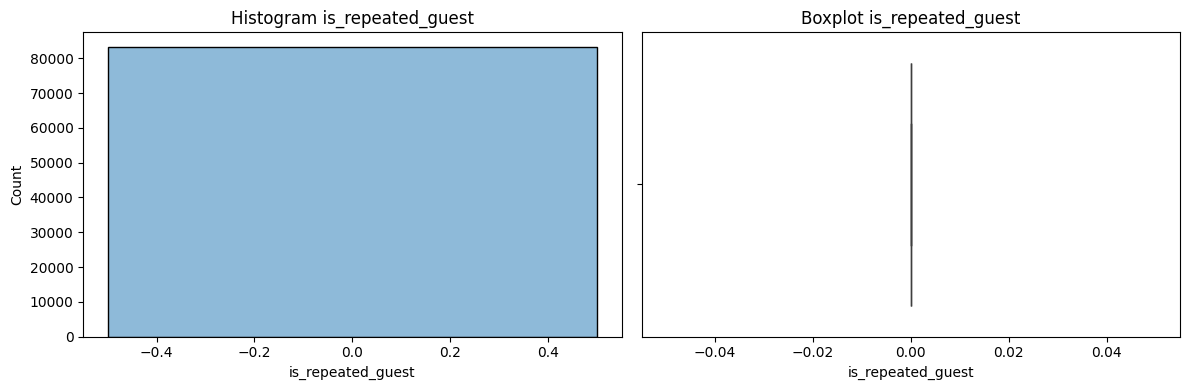

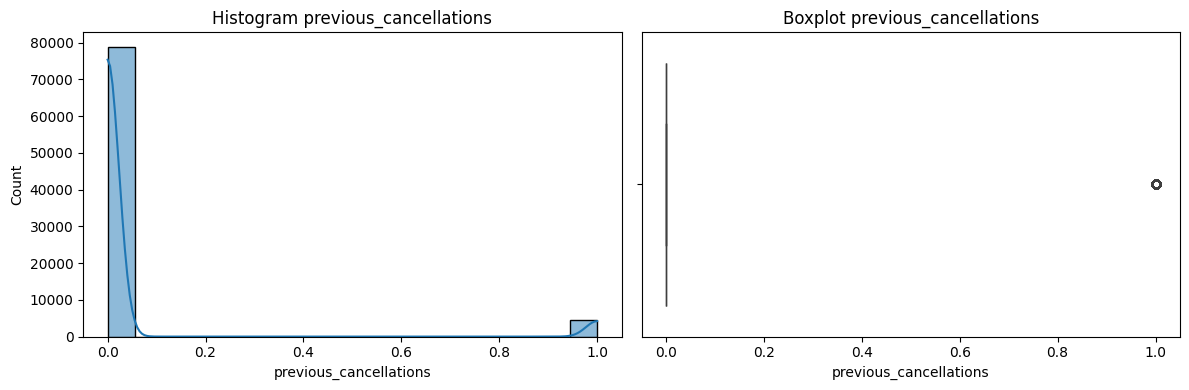

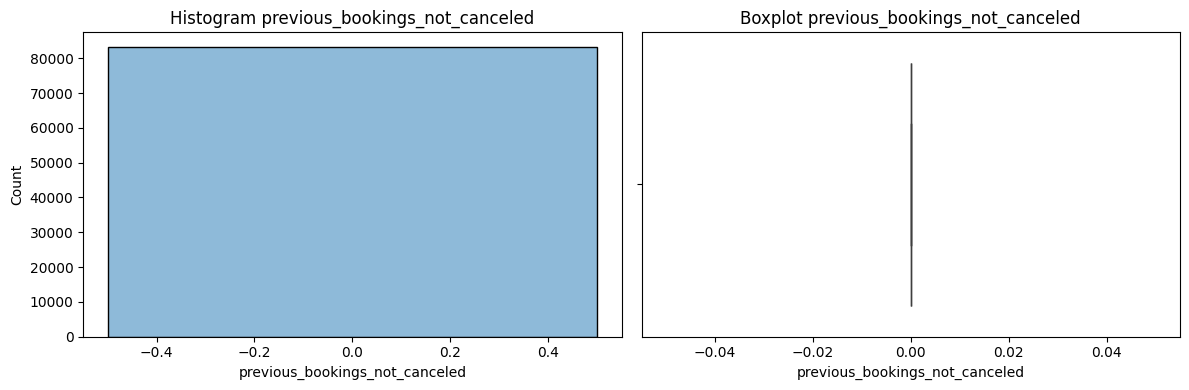

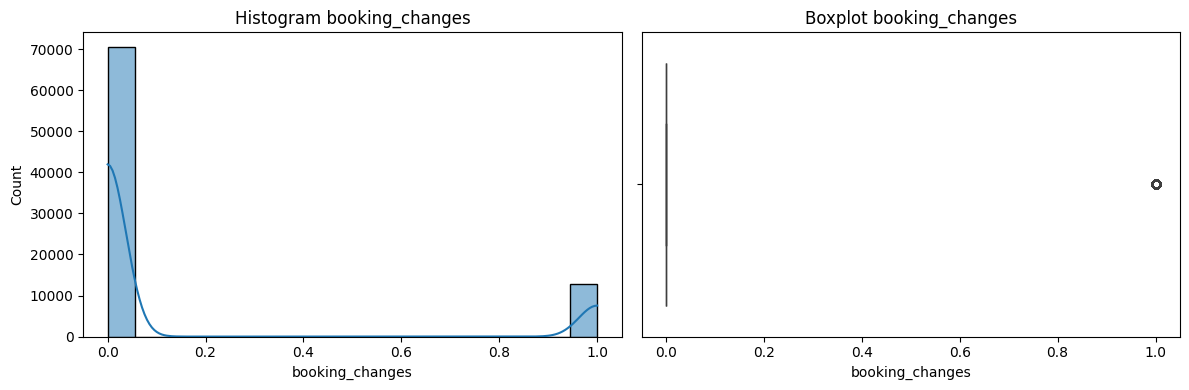

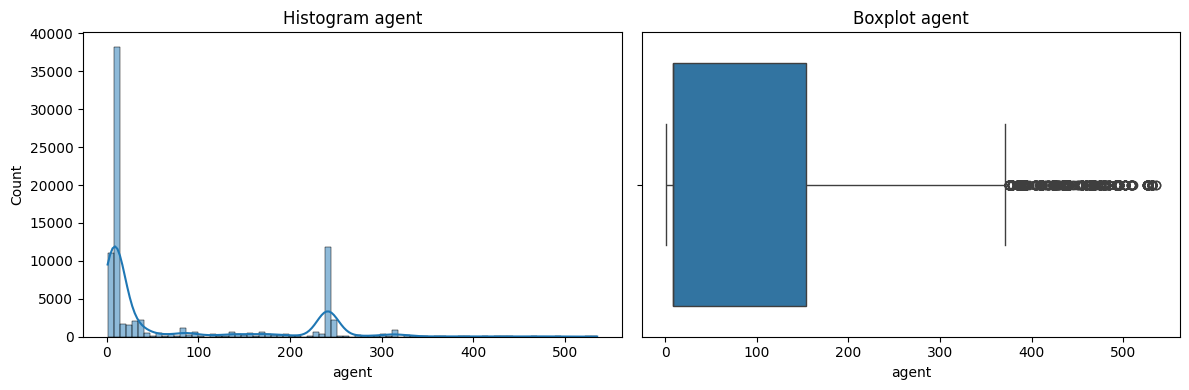

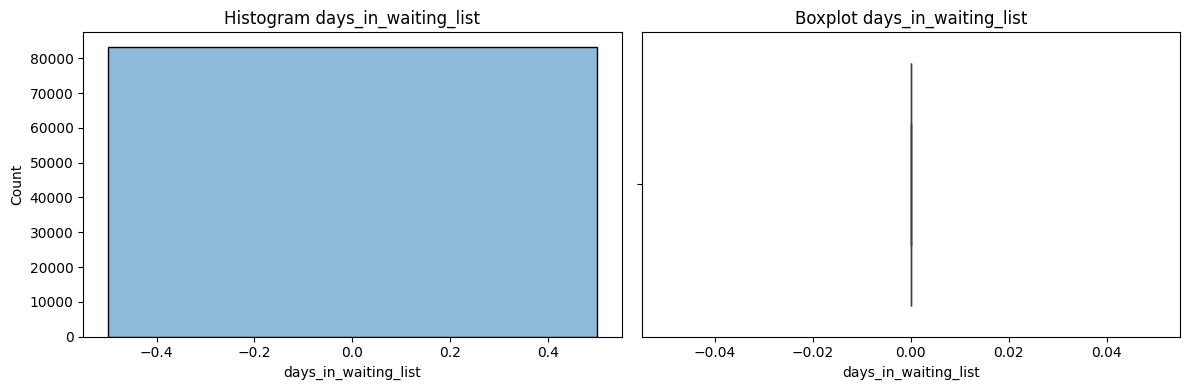

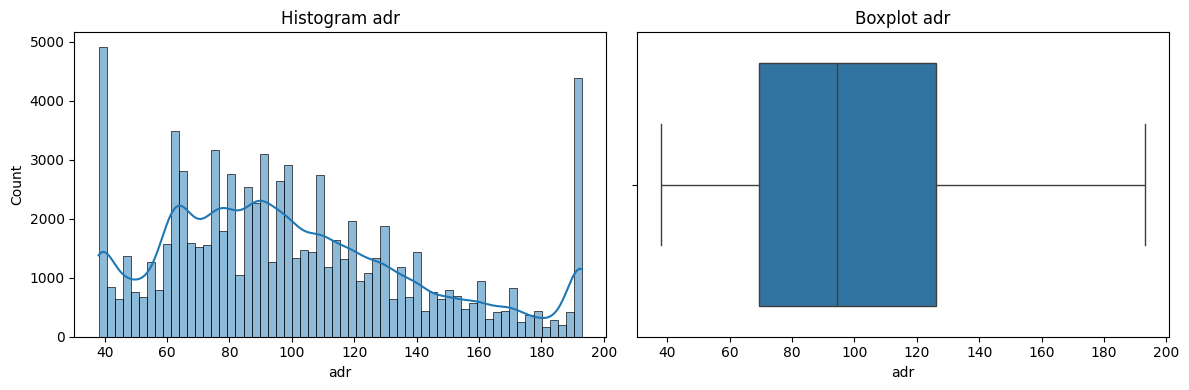

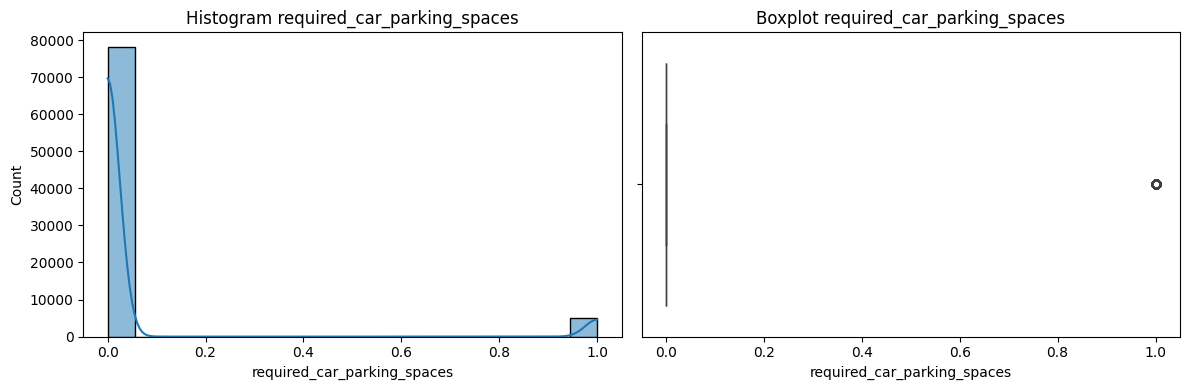

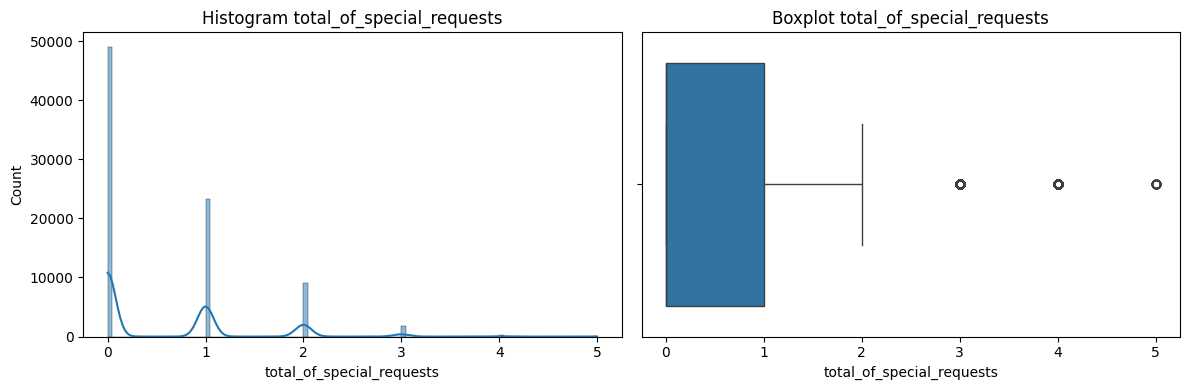

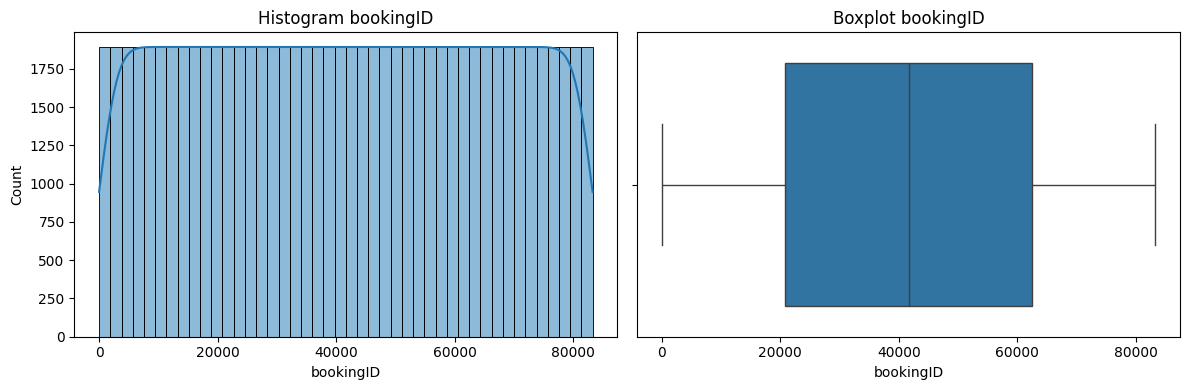

In [ ]:

kolom = ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number',
         'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
         'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
         'previous_bookings_not_canceled', 'booking_changes', 'agent',
         'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
         'total_of_special_requests', 'bookingID']

for col in kolom:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], ax=ax[0], kde=True)
    ax[0].set_title(f'Histogram {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83293 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

## Feature Engineering

### Datetime

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83293 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

In [ ]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'bookingID'],
      dtype='object')

In [ ]:
df[['arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month']].head(10)

,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month
0,2019,January,2,10
1,2018,December,51,15
2,2019,May,20,19
3,2018,October,43,17
4,2017,September,39,26
5,2018,March,13,21
6,2019,June,24,13
7,2018,July,29,12
8,2017,October,40,3
9,2018,July,31,29


In [ ]:
df['arrivaldate'] = pd.to_datetime(df.apply(lambda x: f"{x['arrival_date_year']}-{x['arrival_date_month']}-{x['arrival_date_day_of_month']}", axis=1), errors='coerce')

In [ ]:
df['arrivaldate'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 83293 entries, 0 to 83292
Series name: arrivaldate
Non-Null Count  Dtype         
--------------  -----         
83228 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 650.9 KB


In [ ]:
df = df.drop(['arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month'], axis=1)

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'bookingID',
       'arrivaldate'],
      dtype='object')

In [ ]:
kolom = ['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
         'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
         'country', 'market_segment', 'distribution_channel', 'is_repeated_guest',
         'previous_cancellations', 'previous_bookings_not_canceled',
         'reserved_room_type', 'assigned_room_type', 'booking_changes',
         'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type',
         'adr', 'required_car_parking_spaces', 'total_of_special_requests',
         'reservation_status', 'reservation_status_date', 'bookingID', 'arrivaldate']

for col in kolom:
    unique_values = df[col].unique()
    num_unique_values = len(unique_values)
    data_type = df[col].dtype
    print(f"Kolom: {col}")
    print(f"Data Type: {data_type}")
    print(f"Unique Values: {unique_values}")
    print(f"Jumlah Unique Values: {num_unique_values}")
    print("\n")

Kolom: hotel
Data Type: object
Unique Values: ['Crystal Cove, Barbados Barbados' 'Greensboro Courtyard Greensboro, NC'
 'The Westin Peachtree Plaza, Atlanta Atlanta, GA '
 'Courtyard by Marriott Aberdeen Airport Aberdeen, United Kingdom'
 'W New York – Union Square New York, NY'
 'Hotel Maria Cristina, San Sebastian San Sebastian, Spain'
 'W New York – Times Square New York, NY'
 'The Ritz-Carlton, Tokyo Tokyo, Japan'
 'Marriott Puerto Vallarta Resort & Spa Puerto Vallarta, Mexico'
 'Las Vegas Marriott Las Vegas, NV '
 'Heidelberg Marriott Hotel Heidelberg, Germany'
 'Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil'
 'Renaissance Hamburg Hotel Hamburg, Germany'
 'The Ritz-Carlton, Berlin Berlin, Germany'
 'Sheraton Lima Hotel & Convention Center Lima, Peru'
 'Courtyard Las Vegas Convention Center Las Vegas, NV '
 'Newark Liberty International Airport Courtyard Newark, NJ'
 'Indianapolis Airport Courtyard Indianapolis, IN'
 'Treasure Beach, Barbados Barbados'
 'Cape Town Marrio

In [ ]:
kolom = ['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
         'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
         'country', 'market_segment', 'distribution_channel', 'is_repeated_guest',
         'previous_cancellations', 'previous_bookings_not_canceled',
         'reserved_room_type', 'assigned_room_type', 'booking_changes',
         'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type',
         'adr', 'required_car_parking_spaces', 'total_of_special_requests',
         'reservation_status', 'reservation_status_date', 'bookingID', 'arrivaldate']

undefined_info = []
for col in kolom:
    undefined_count = df[col].eq('Undefined').sum()
    undefined_percentage = (undefined_count / len(df)) * 100
    if undefined_count > 0:
        undefined_info.append({
            'Kolom': col,
            'Jumlah Undefined': undefined_count,
            'Persentase Undefined': undefined_percentage,
            'Contoh Data': df[df[col] == 'Undefined'].head().to_dict('records')
        })

undefined_df = pd.DataFrame(undefined_info).sort_values(by='Persentase Undefined', ascending=False)
print(undefined_df)


                  Kolom  Jumlah Undefined  Persentase Undefined  \
0                  meal               828              0.994081   
2  distribution_channel                 4              0.004802   
1        market_segment                 1              0.001201   

                                         Contoh Data  
0  [{'hotel': 'Renaissance Hamburg Hotel Hamburg,...  
2  [{'hotel': 'Renaissance Hamburg Hotel Hamburg,...  
1  [{'hotel': 'Renaissance Hamburg Hotel Hamburg,...  


Berdasarkan data tersebut dapat diketahui bahwa persentase 'undifined' ini tidak sampai 1 persen artinya bisa diganti dengan nilai modusnya.

In [ ]:
kolom = ['meal', 'distribution_channel', 'market_segment']

for col in kolom:
    modus = df[col].mode()[0]
    df[col] = df[col].replace('Undefined', modus)
    print(f"Kolom {col} telah digantikan dengan modus: {modus}")

Kolom meal telah digantikan dengan modus: BB
Kolom distribution_channel telah digantikan dengan modus: TA/TO
Kolom market_segment telah digantikan dengan modus: Online TA


In [ ]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/Penyaluran Kerja/Interview Data Analyst/ds/databersih.csv', index=False)

# EDA

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Penyaluran Kerja/Interview Data Analyst/ds/databersih.csv')
df2.head(10)

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,arrivaldate
0,"Crystal Cove, Barbados Barbados",0,8,0,4,2,0.0,0,BB,ITA,...,314.0,0,Transient,38.40,0,0,Check-Out,2019-01-14,1,2019-01-10
1,"Greensboro Courtyard Greensboro, NC",1,524,0,2,2,0.0,0,BB,PRT,...,1.0,0,Transient,62.80,0,0,Canceled,2017-10-21,2,2018-12-15
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,1,2,2,0.0,0,BB,PRT,...,12.0,0,Transient,110.00,0,0,Canceled,2018-11-25,3,2019-05-19
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,1,0,1,0.0,0,BB,PRT,...,9.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4,2018-10-17
4,"W New York – Union Square New York, NY",1,33,2,3,2,0.0,0,BB,PRT,...,16.0,0,Transient,57.92,0,1,Canceled,2017-08-24,5,2017-09-26
5,"Hotel Maria Cristina, San Sebastian San Sebast...",1,395,1,2,2,0.0,0,BB,PRT,...,1.0,0,Transient,62.80,0,0,Canceled,2017-08-10,6,2018-03-21
6,"W New York – Times Square New York, NY",0,205,0,4,2,0.0,0,BB,BEL,...,9.0,0,Transient,150.75,0,2,Check-Out,2019-06-17,7,2019-06-13
7,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,52,0,2,3,0.0,0,BB,DNK,...,9.0,0,Transient,137.70,0,1,Check-Out,2018-07-14,8,2018-07-12
8,Marriott Puerto Vallarta Resort & Spa Puerto V...,0,44,4,5,2,0.0,0,HB,GBR,...,314.0,0,Contract,77.84,0,0,Check-Out,2017-10-13,9,2017-10-03
9,"Las Vegas Marriott Las Vegas, NV",1,167,0,2,2,0.0,0,SC,IRL,...,9.0,0,Transient,94.50,0,0,Canceled,2018-07-24,10,2018-07-29


In [ ]:
df2.describe()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,bookingID
count,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.0,83293.000000,83293.0,83293.000000,83293.000000,83293.0,83293.000000,83293.000000,83293.000000,83293.000000
mean,0.369503,103.914230,0.930390,2.366129,1.853769,0.071567,0.008032,0.0,0.052790,0.0,0.152510,76.206140,0.0,100.751771,0.061338,0.571945,41647.000000
std,0.482673,106.874124,1.004196,1.446307,0.479355,0.257771,0.100641,0.0,0.223614,0.0,0.359517,106.427161,0.0,41.278783,0.239950,0.793742,24044.762323
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,0.0,38.058000,0.000000,0.000000,1.000000
25%,0.000000,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,9.000000,0.0,69.530000,0.000000,0.000000,20824.000000
50%,0.000000,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,9.000000,0.0,94.500000,0.000000,0.000000,41647.000000
75%,1.000000,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,154.000000,0.0,126.000000,0.000000,1.000000,62470.000000
max,1.000000,737.000000,19.000000,5.000000,3.000000,1.000000,10.000000,0.0,1.000000,0.0,1.000000,535.000000,0.0,193.000000,1.000000,5.000000,83293.000000


In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'bookingID',
       'arrivaldate'],
      dtype='object')

 1. Analisis Pembatalan 


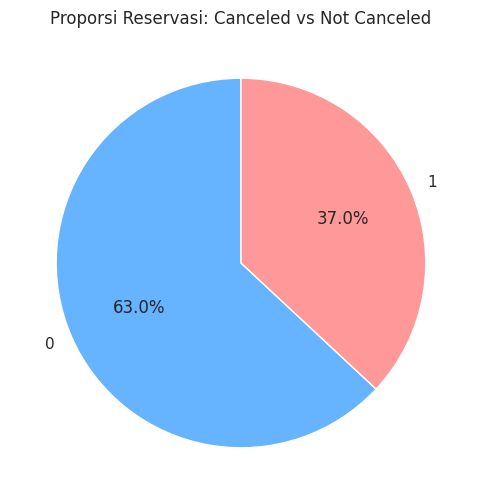

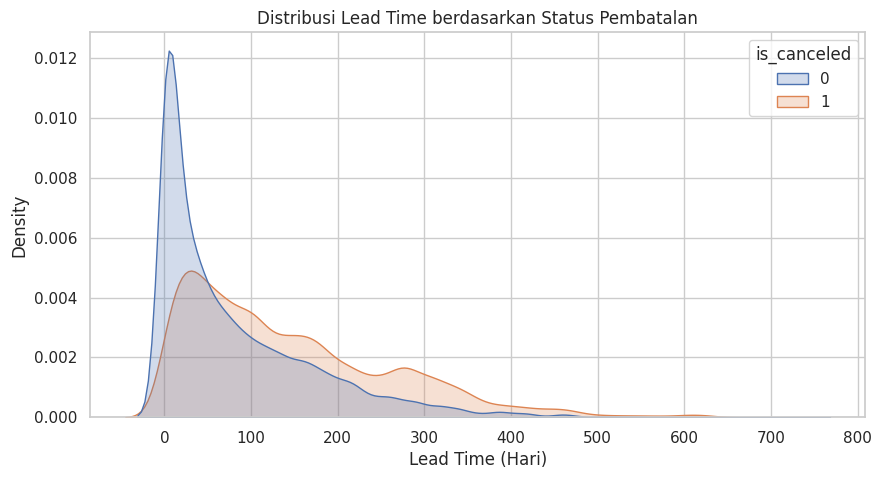

In [ ]:
import seaborn as sns
import plotly.express as px

# Setting tema visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df['arrivaldate'] = pd.to_datetime(df['arrivaldate'])
# Membuat kolom total stay
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
# Membuat kolom total tamu
df['total_guests'] = df['adults'] + df['children'] + df['babies']

print(" 1. Analisis Pembatalan ")

plt.figure(figsize=(6, 6))
df['is_canceled'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Proporsi Reservasi: Canceled vs Not Canceled')
plt.ylabel('')
plt.show()

# Hubungan Lead Time dengan Pembatalan
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, common_norm=False)
plt.title('Distribusi Lead Time berdasarkan Status Pembatalan')
plt.xlabel('Lead Time (Hari)')
plt.show()

 2. Analisis ADR (Average Daily Rate) 


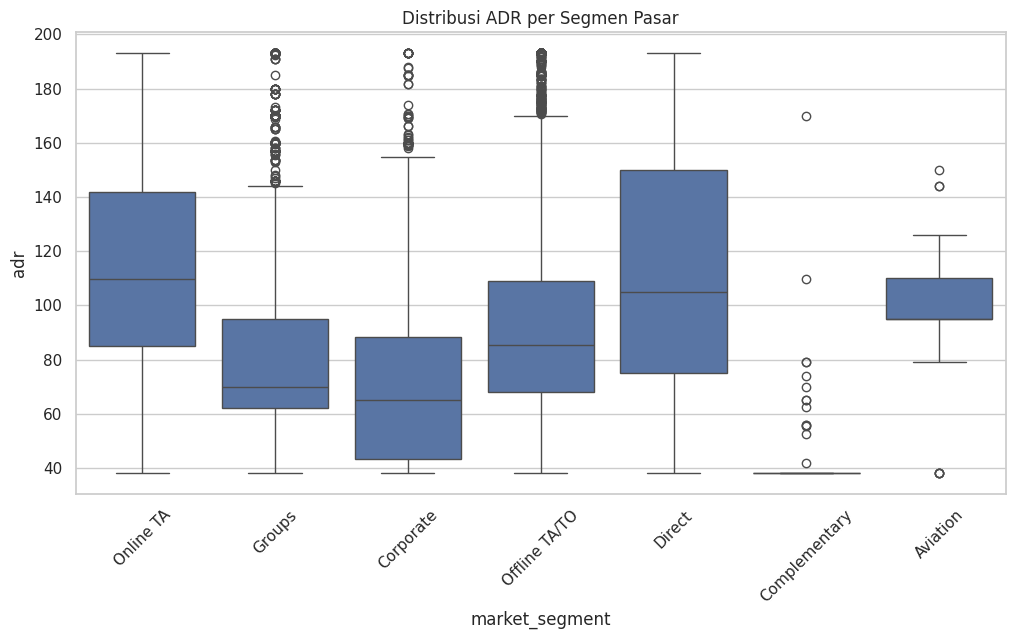

In [ ]:
print(" 2. Analisis ADR (Average Daily Rate) ")

# Tren ADR Bulanan
df['arrival_month'] = df['arrivaldate'].dt.to_period('M').astype(str)
adr_trend = df.groupby('arrival_month')['adr'].mean().reset_index()

fig = px.line(adr_trend, x='arrival_month', y='adr', title='Tren Rata-rata Harga Harian (ADR) per Bulan')
fig.show()

# ADR berdasarkan Market Segment
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='market_segment', y='adr')
plt.title('Distribusi ADR per Segmen Pasar')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Top 10 Asal Negara Tamu
top_countries = df['country'].value_counts().head(10).reset_index()

# Di Pandas baru, kolomnya adalah 'country' dan 'count'
fig = px.bar(top_countries,
             x='country',  # Nama negaranya
             y='count',    # Jumlahnya
             labels={'country':'Country', 'count':'Number of Bookings'},
             title='10 Negara Asal Tamu Terbanyak')
fig.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           83293 non-null  object        
 1   is_canceled                     83293 non-null  int64         
 2   lead_time                       83293 non-null  int64         
 3   stays_in_weekend_nights         83293 non-null  int64         
 4   stays_in_week_nights            83293 non-null  int64         
 5   adults                          83293 non-null  int64         
 6   children                        83293 non-null  float64       
 7   babies                          83293 non-null  int64         
 8   meal                            83293 non-null  object        
 9   country                         83293 non-null  object        
 10  market_segment                  83293 non-null  object        
 11  di

## Kolom Revenue

In [ ]:
# Menghitung total durasi menginap (malam)
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Menghitung Revenue
# Rumus: ADR * Total Malam, namun diset ke 0 jika pesanan dibatalkan (is_canceled == 1)
df['revenue'] = df['adr'] * df['total_stay_nights']
df.loc[df['is_canceled'] == 1, 'revenue'] = 0

# Cek hasilnya
print(df[['bookingID', 'adr', 'total_stay_nights', 'is_canceled', 'revenue']].head())

   bookingID     adr  total_stay_nights  is_canceled  revenue
0          1   38.40                  4            0    153.6
1          2   62.80                  2            1      0.0
2          3  110.00                  3            1      0.0
3          4   45.00                  1            0     45.0
4          5   57.92                  5            1      0.0


In [ ]:
# ANALISIS TOTAL REVENUE (BUSINESS GOAL 4)
print("###Analisis Tren Pendapatan (Revenue) ###")

#Pastikan kolom revenue sudah dihitung (Hanya untuk is_canceled == 0)
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue'] = df['adr'] * df['total_stay']
df.loc[df['is_canceled'] == 1, 'revenue'] = 0

#Mengelompokkan berdasarkan bulan dan menjumlahkan (SUM) revenue
revenue_trend = df.groupby('arrival_month')['revenue'].sum().reset_index()

#Visualisasi Line Chart menggunakan Plotly
fig = px.line(revenue_trend,
              x='arrival_month',
              y='revenue',
              title='Tren Total Pendapatan (Revenue) per Bulan',
              markers=True, # Menambahkan titik pada setiap bulan agar lebih jelas
              labels={'revenue': 'Total Revenue (€)', 'arrival_month': 'Bulan Kedatangan'},
              color_discrete_sequence=['#2ecc71']) # Warna hijau untuk melambangkan uang/pendapatan

# Mempercantik tampilan sumbu Y agar tidak menggunakan notasi ilmiah
fig.update_layout(yaxis_tickformat='€,.2f')

fig.show()

###Analisis Tren Pendapatan (Revenue) ###


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Menyiapkan Data (Agregasi Bulanan)
# Menghitung Rata-rata ADR dan Total Pesanan per Bulan
trend_data = df.groupby('arrival_month').agg({
    'adr': 'mean',
    'bookingID': 'count'
}).reset_index()

# Membuat Grafik dengan Dua Sumbu Y
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Tambahkan Garis Volume Pemesanan (Sumbu Y Kiri)
fig.add_trace(
    go.Scatter(x=trend_data['arrival_month'], y=trend_data['bookingID'],
               name="Volume Pemesanan", mode='lines+markers',
               line=dict(color='#3498db', width=3)),
    secondary_y=False,
)

# Tambahkan Garis Tren ADR (Sumbu Y Kanan)
fig.add_trace(
    go.Scatter(x=trend_data['arrival_month'], y=trend_data['adr'],
               name="Rata-rata ADR (€)", mode='lines+markers',
               line=dict(color='#e67e22', width=3, dash='dot')),
    secondary_y=True,
)

# Mengatur Layout
fig.update_layout(
    title_text="Perbandingan Volume Pemesanan vs Tren Harga (ADR) Bulanan",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Memberi Label Sumbu
fig.update_yaxes(title_text="<b>Volume</b> (Jumlah Pesanan)", secondary_y=False)
fig.update_yaxes(title_text="<b>Harga</b> (Average Daily Rate)", secondary_y=True)

fig.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Memilih fitur yang relevan berdasarkan EDA kita sebelumnya
features = [
    'lead_time', 'total_stay', 'adr', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'deposit_type', 'market_segment', 'customer_type'
]

X = df[features].copy()
y = df['is_canceled']

In [ ]:
#PREPROCESSING (ENCODING)
# Mengubah data teks menjadi angka agar bisa diproses model
le = LabelEncoder()
categorical_cols = ['deposit_type', 'market_segment', 'customer_type']

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

In [ ]:
#SPLIT DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#TRAINING MODEL
print("Melatih Model Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

Melatih Model Random Forest...


RandomForestClassifier(random_state=42)

In [ ]:
#EVALUASI
y_pred = model.predict(X_test)

print("\n Model Performance ")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


 Model Performance 
Accuracy Score: 79.43%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     10472
           1       0.75      0.68      0.71      6187

    accuracy                           0.79     16659
   macro avg       0.78      0.77      0.78     16659
weighted avg       0.79      0.79      0.79     16659



In [ ]:
#FEATURE IMPORTANCE
# Melihat variabel apa yang paling menentukan pembatalan
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Variabel Paling Berpengaruh ")
print(importance)


 Variabel Paling Berpengaruh 
                          Feature  Importance
0                       lead_time    0.319129
2                             adr    0.297046
6                    deposit_type    0.195441
1                      total_stay    0.057626
7                  market_segment    0.056162
4          previous_cancellations    0.047630
8                   customer_type    0.026967
3               is_repeated_guest    0.000000
5  previous_bookings_not_canceled    0.000000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

#PREPROCESSING
# Memastikan fitur kategori sudah di-encode
le = LabelEncoder()
categorical_cols = ['deposit_type', 'market_segment', 'customer_type']
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

In [ ]:
# Scalling data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
#DEFINISI MODEL
models = {
    "Logistic Regression": LogisticRegression(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

#TRAINING & EVALUATION
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Hitung Metrik
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[23:05:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




In [ ]:
#TAMPILKAN HASIL
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("### Perbandingan Performa Model ###")
print(df_results)

### Perbandingan Performa Model ###
                 Model  Accuracy  Precision    Recall  F1-Score
2              XGBoost  0.789543   0.819699  0.555520  0.662235
1    Gradient Boosting  0.774716   0.874923  0.459027  0.602141
0  Logistic Regression  0.765892   0.923048  0.403265  0.561305
